In [1]:

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import uproot
import torch
from torch import nn, optim
import pathlib
import os
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import QuantileTransformer, PowerTransformer
#https://link.springer.com/content/pdf/10.1007/978-981-96-7005-5.pdf
# https://www.youtube.com/watch?v=qiUEgSCyY5o

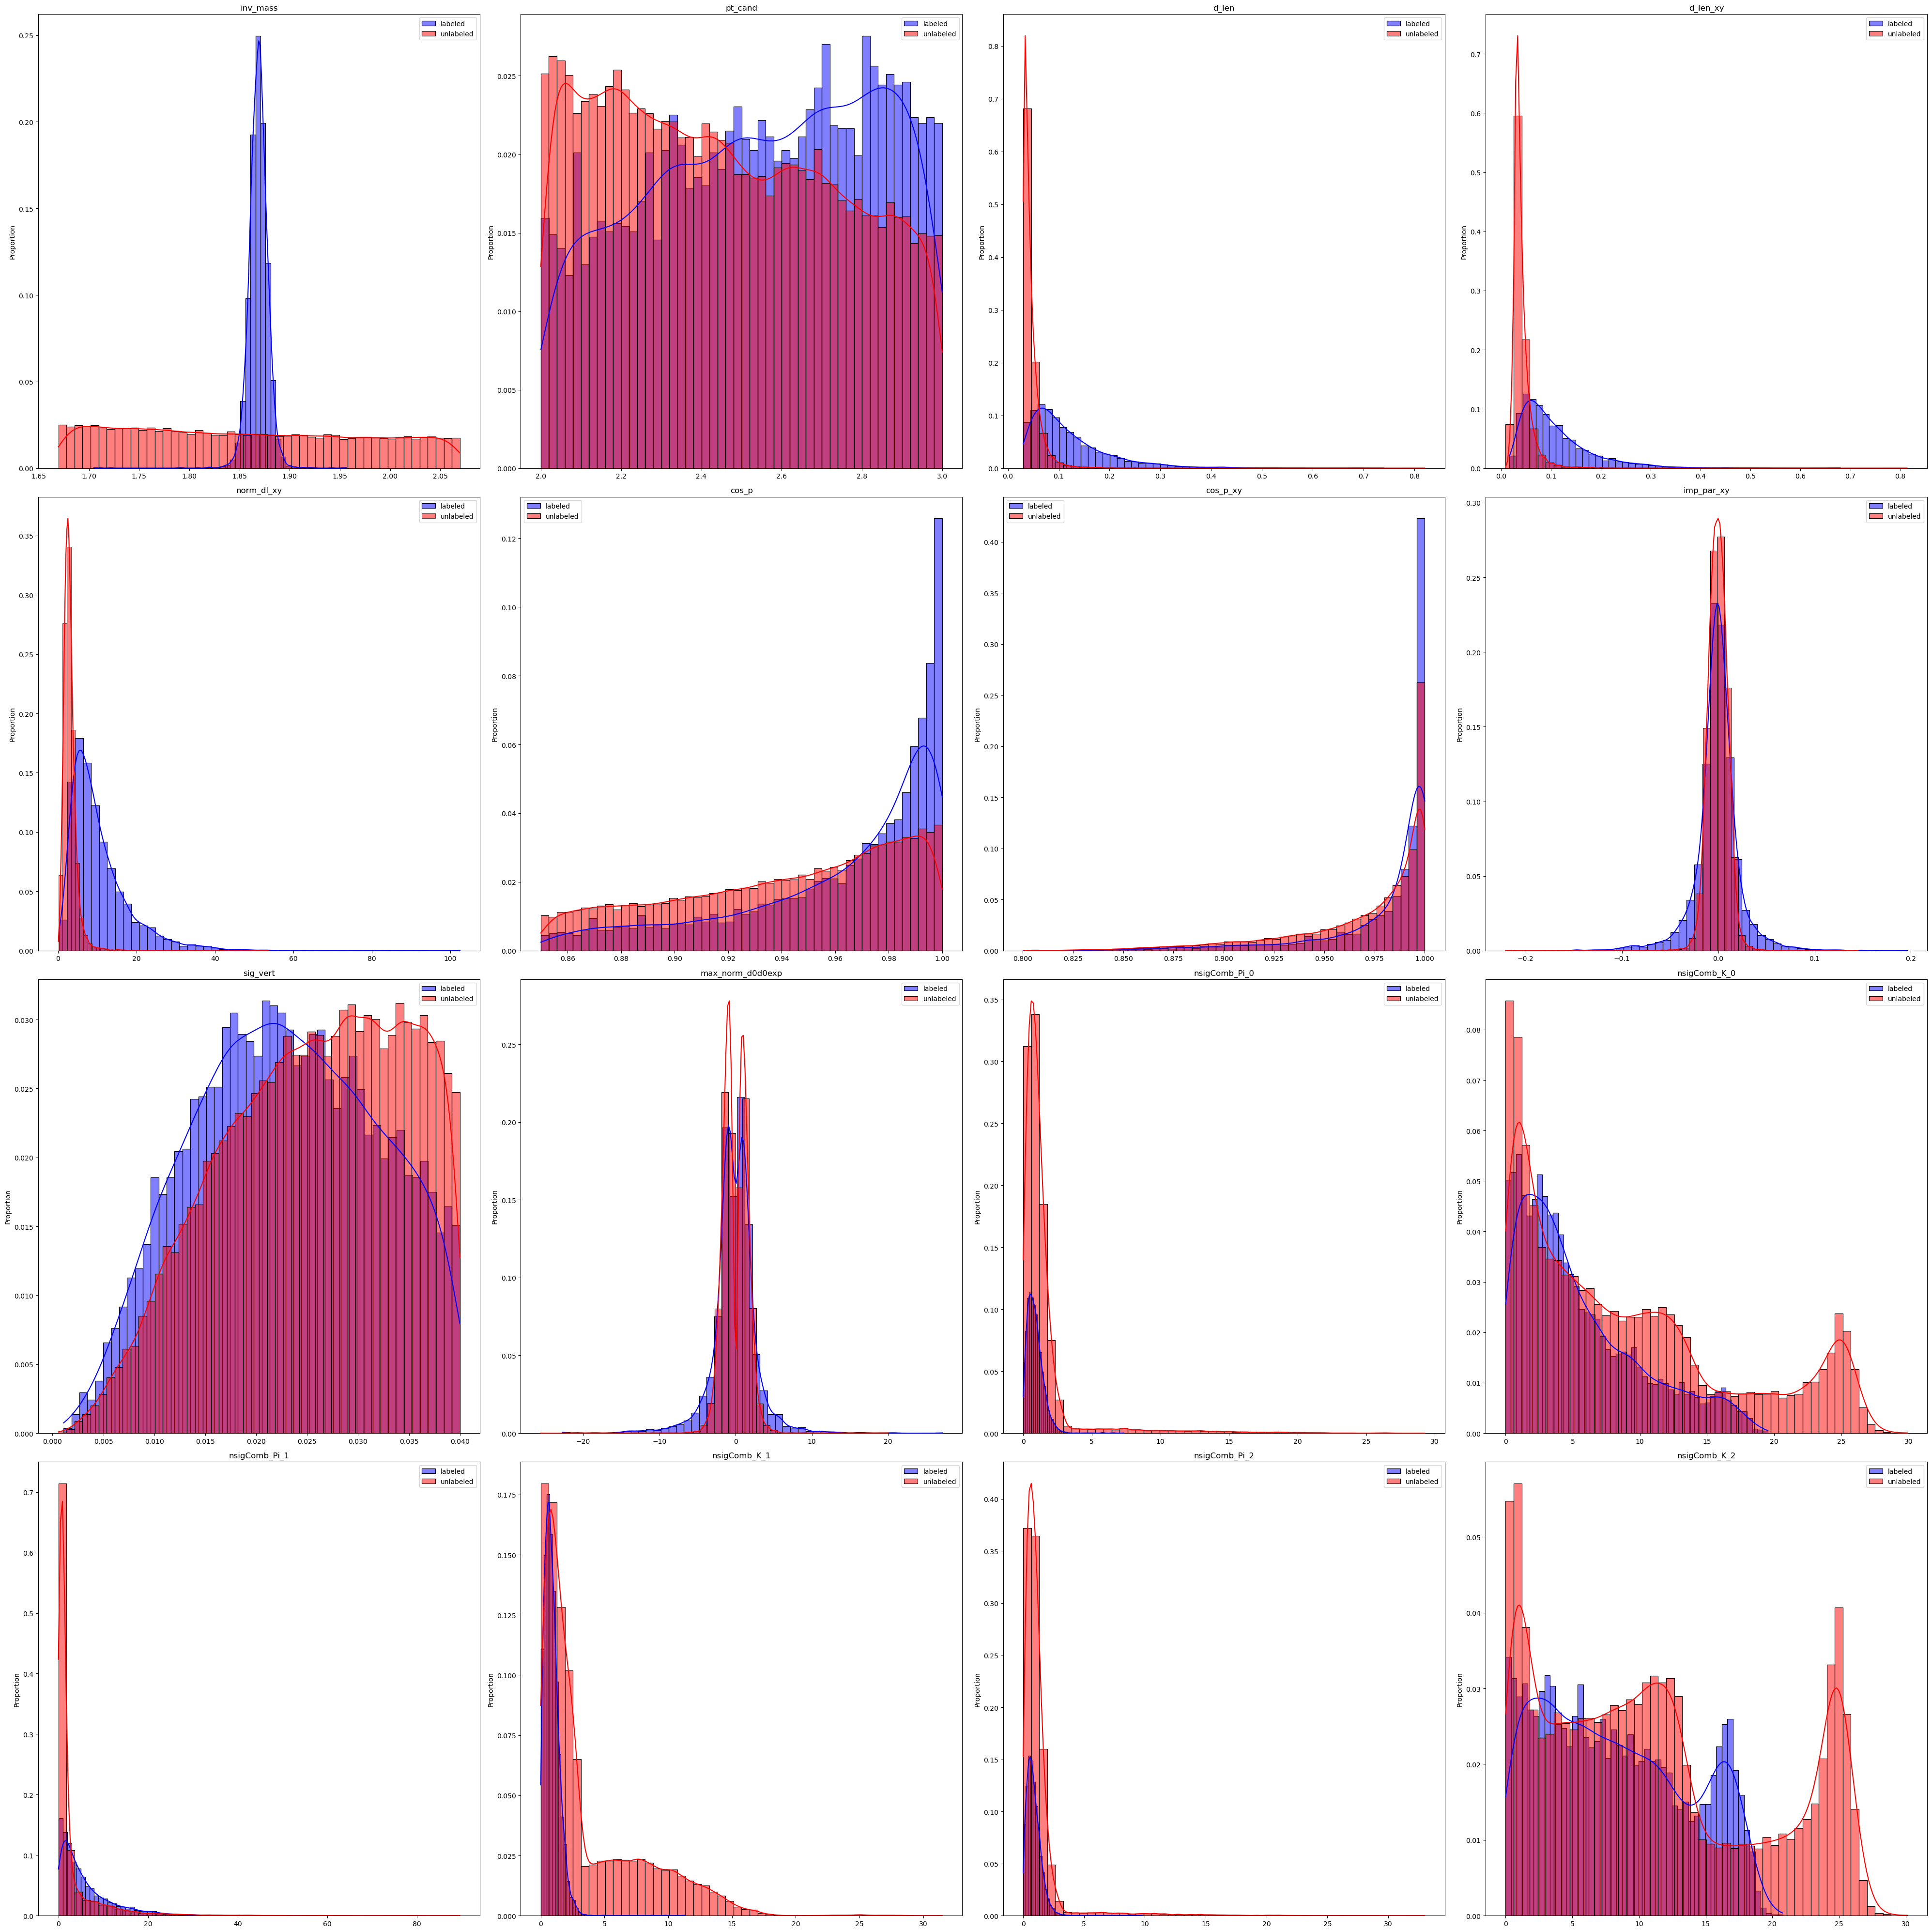

In [2]:
## _-------------------------- Inladen van de data uit de data bestanden

def loader_to_tensor(loader):
    all_data = []
    for batch in loader:
        # batch is a tuple (features,) because no labels
        all_data.append(batch[0])
    return torch.cat(all_data, dim=0)

# Get the data of the simulated outliers.
with uproot.open(pathlib.Path(r"Training_Data\FD.root")) as file:
    tree = file['treeMLDplus']
    branches = tree.keys()
    training_data_FD = tree.arrays(branches, library="np")
    labeled_anomaly_data_tensor = torch.tensor(pd.DataFrame(training_data_FD).values)

# Get the unlabeled data. Since this data file is very large and we do not use all of it for training, limit to 10.000 datapoints for now
with uproot.open(pathlib.Path(r"Training_Data\data.root")) as file_test:
    tree_test = file_test['treeMLDplus']
    branches_test = tree_test.keys()
    training_data_bkg = tree_test.arrays(branches_test, library="np")
    training_data_bkg_df = pd.DataFrame(training_data_bkg)
    unlabeled_data_tensor = torch.tensor(training_data_bkg_df.values)[:100000]


fig, axes = plt.subplots(4,4, figsize=(40, 40))
axes = axes.flatten()
for i, col in enumerate(branches):
    sns.histplot(labeled_anomaly_data_tensor[:, i], bins=50, color='blue', alpha=0.5, label='labeled', ax=axes[i],kde=True,stat='proportion')
    sns.histplot(unlabeled_data_tensor[:, i], bins=50, color='red', alpha=0.5, label='unlabeled', ax=axes[i],kde=True,stat='proportion')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()



Normaliseer de gelabelede data met een yeo-johnson transformatie, zodat de distributie een mean van 0 heeft en een std van 1. Pas deze transform ook toe op de ongelabelede data.

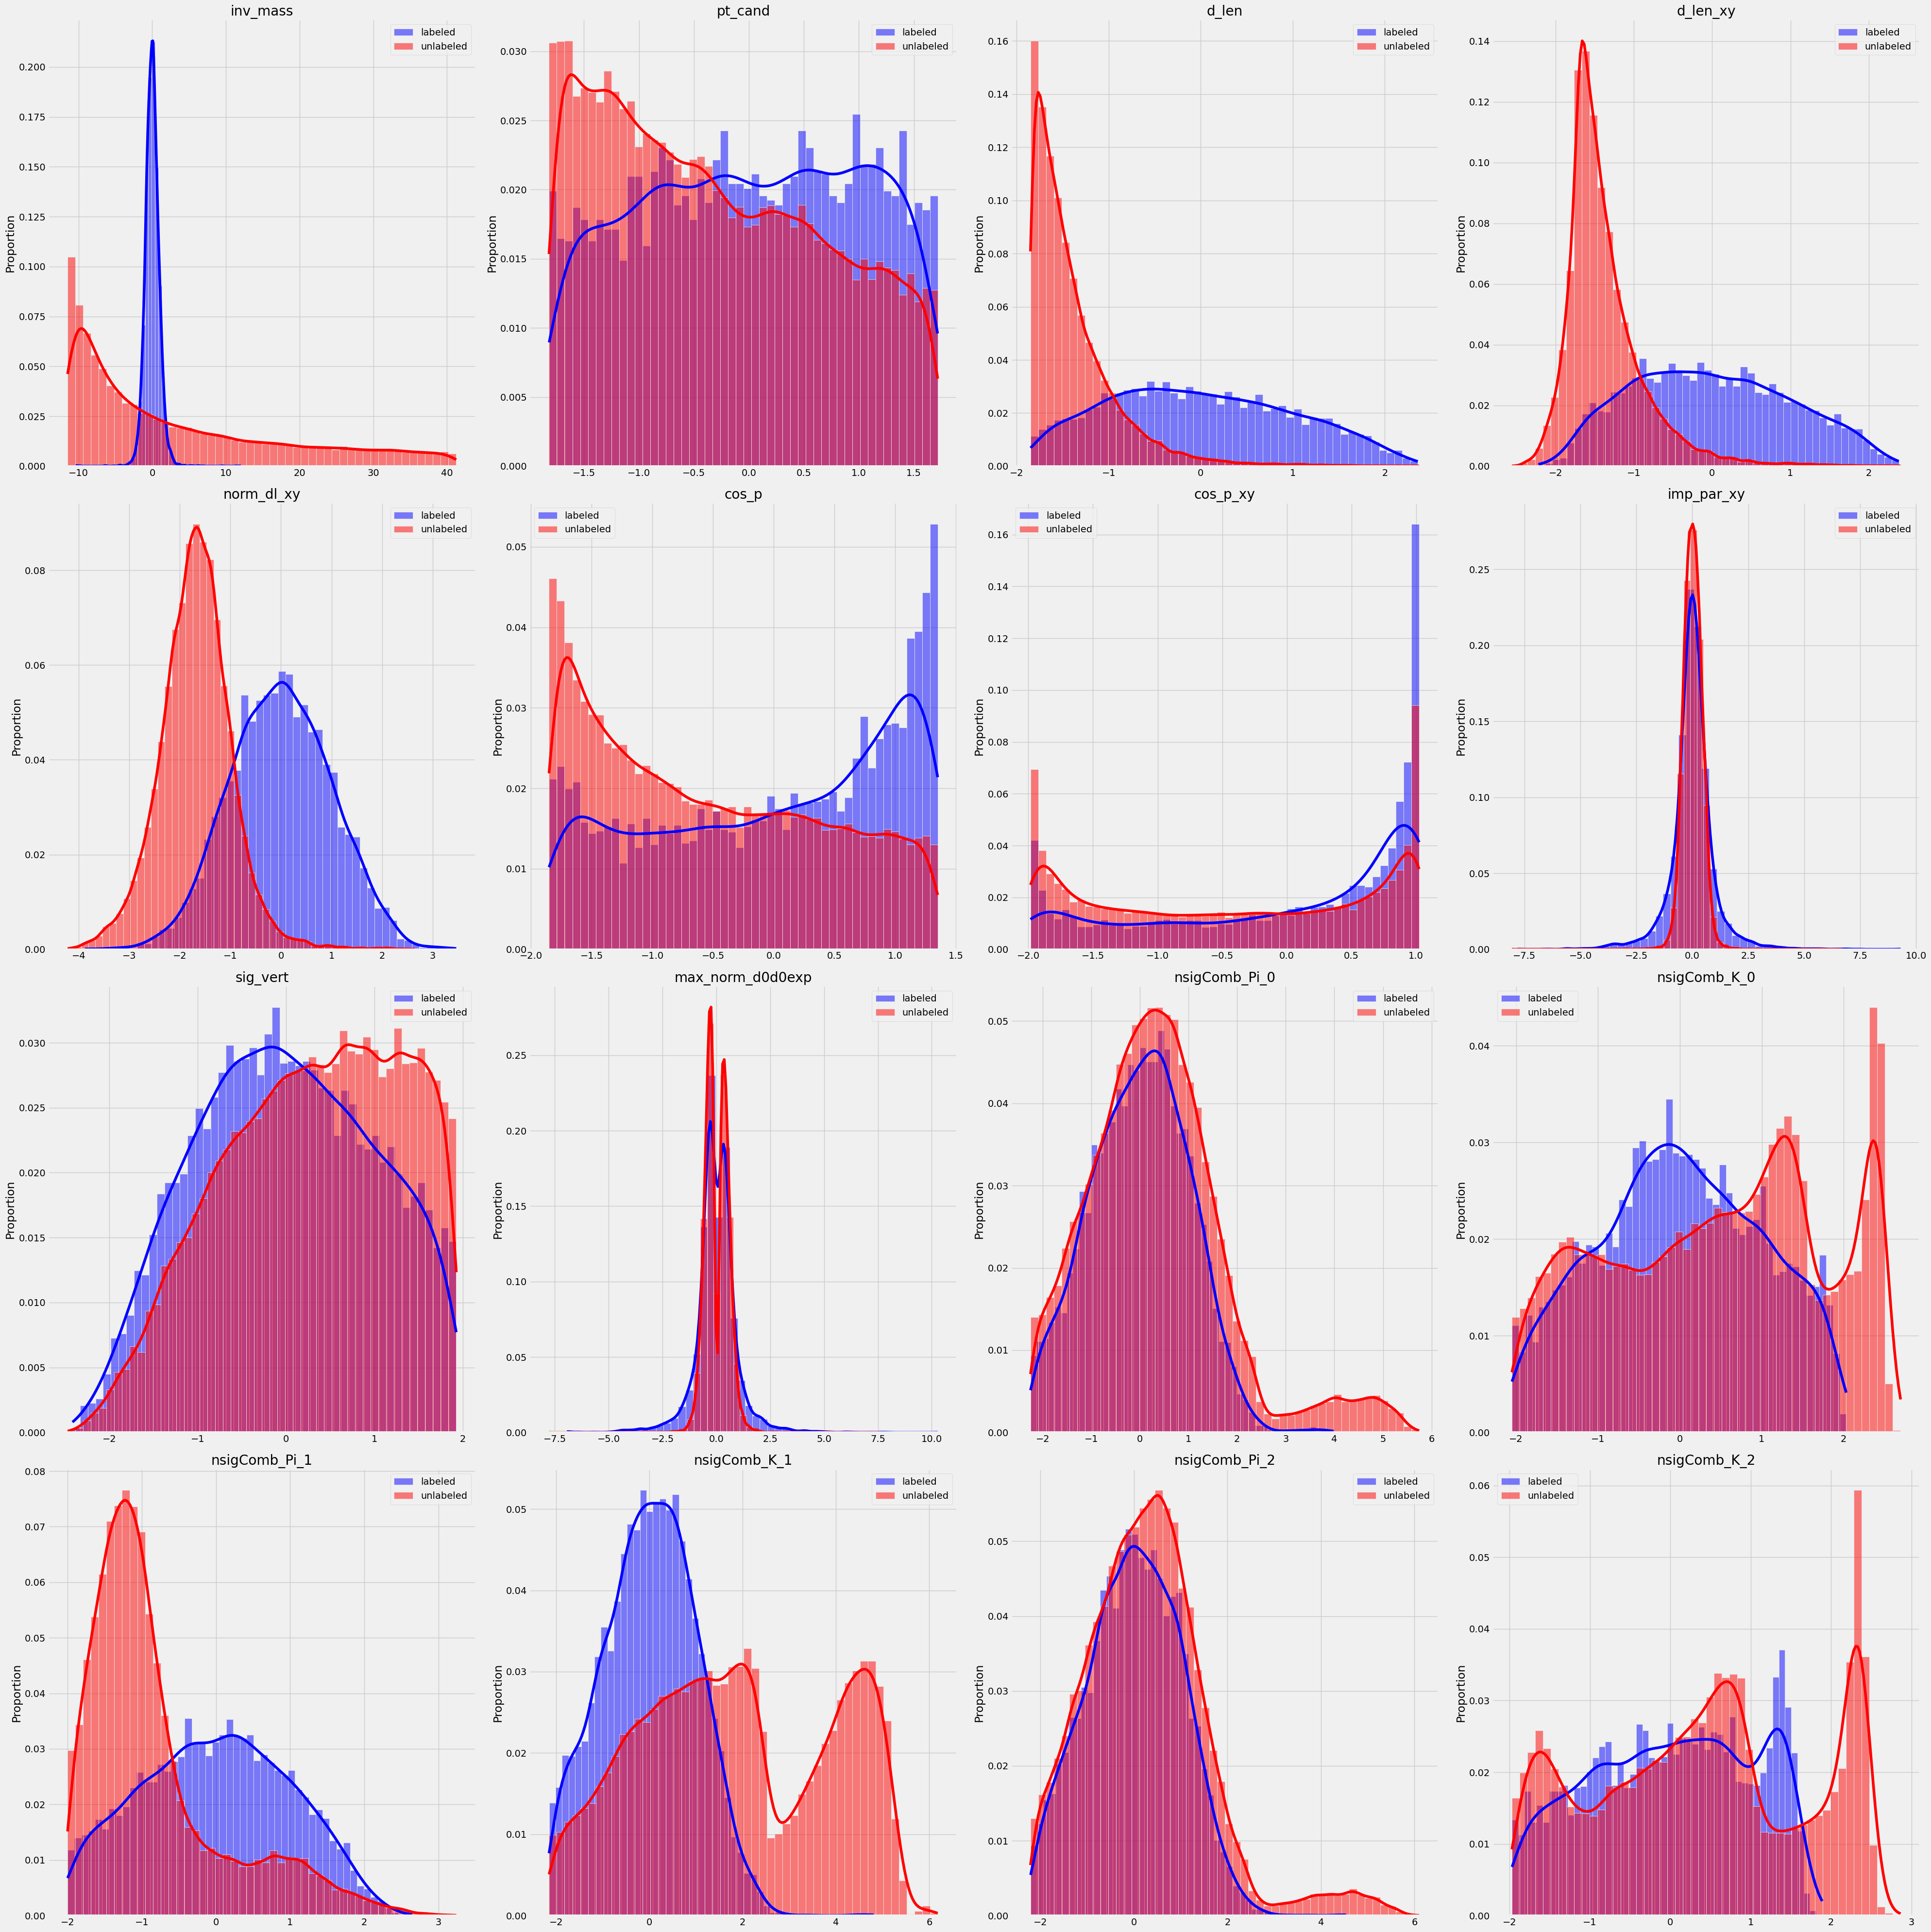

In [13]:
from torch.utils.data import ConcatDataset
# Normalize each feature, according to the type of distribution it seems to follow to optimise performance

#! TODO explain the differences in transformation methods, and why different methods do and do not work here
# de quantiletransformer kan niet worden gefit op de trainingsdata bijvoorbeeld en dan gebruikt op beide, omdat die data buiten bereik van trainingsdata clipt.

qt = PowerTransformer(method="yeo-johnson",standardize=True)
qt.fit(labeled_anomaly_data_tensor)

labeled_anomaly_data_tensor_normalised = qt.transform(labeled_anomaly_data_tensor).astype(np.float32)
label__labeled_data_tensor = torch.tensor(np.ones(labeled_anomaly_data_tensor.shape[0]))
unlabeled_data_tensor_normalised = qt.transform(unlabeled_data_tensor).astype(np.float32)
label_unlabeled_data_tensor = torch.tensor(np.zeros(unlabeled_data_tensor_normalised.shape[0]))


# Split the data into:
# 1. a labeled anomaly training set, to train the KDAE on
# 2. A mix of labeled anomaly data and unlabeled noise, to verify the KDAE on
labeled_train, labeled_test = train_test_split(labeled_anomaly_data_tensor_normalised,test_size=0.2) # Use this to train the model
# mixed_data_tensor = labeled_test+unlabeled_data_tensor_normalised # Use this to find whether the model can separate the D+ from the not D+

fig, axes = plt.subplots(4,4, figsize=(40, 40))
axes = axes.flatten()
for i, col in enumerate(branches):
    sns.histplot(labeled_anomaly_data_tensor_normalised[:, i], bins=50, color='blue', alpha=0.5, label='labeled', ax=axes[i],kde=True,stat='proportion')
    sns.histplot(unlabeled_data_tensor_normalised[:, i], bins=50, color='red', alpha=0.5, label='unlabeled', ax=axes[i],kde=True,stat='proportion')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()
# dataset_test = TensorDataset(features_test)     # No labels
# loader_test = DataLoader(dataset_test, batch_size=2000, shuffle=True)
labeled_tensor = torch.tensor(labeled_anomaly_data_tensor_normalised)
unlabeled_tensor = torch.tensor(unlabeled_data_tensor_normalised)

# train_data, val_data = random_split(labeled_tensor, [1200, 600])
labeled_dataset = TensorDataset(labeled_tensor,label__labeled_data_tensor)
unlabeled_dataset = TensorDataset(unlabeled_tensor,label_unlabeled_data_tensor)

train_size = int(0.8 * len(labeled_dataset))
test_size = len(labeled_dataset) - train_size

# Split the dataset
KDAE_train_dataset, labeled_test_dataset = random_split(labeled_dataset, [train_size,test_size],generator=torch.Generator().manual_seed(42))

# 
loader_noise_data = DataLoader(unlabeled_dataset)
loader_KDAE_train_data = DataLoader(KDAE_train_dataset, batch_size=2000, shuffle=True)
KDAE_test_data = ConcatDataset([labeled_test_dataset,unlabeled_dataset])
loader_mixed_data = DataLoader(KDAE_test_data, batch_size=2000, shuffle=True)


Definieer de Auto Encoder

In [4]:
# Definieer een auto encoder neural network. Dit type neural network bgint met de volledige 16 parameters, comprimeert ze in steeds kleinere lagen
# Totdat het de kleinste laag van maar twee neuronen bereikt. Daarna probeert het hiermee weer de originele parameters te recreeëren
# Dit model leert dus voor het signaal van D+ deeltjes hoe de data er ongeveer uitziet. Het verschil tussen de input en output parameters
# Voor D+ deeltjes zou dus heel klein moeten zijn, en de error dus klein. Maar het model is niet getrained op alle andere deeltjes.
# De verwachting is dus dat andere deeltjes die geen D+ deeltjes zijn, de autoencoder heel slecht zal zijn in de parameters recreeëren zonder extra training.
# Zo kan de error van het netwerk gebruikt worden als classificatie van wel of niet D+ deeltjes.

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.shrinking = nn.Sequential(
            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.1),
            nn.Linear(16, 8),
            # nn.LeakyReLU(0.1),
            # nn.Linear(8, 2)   # 2D latent space for KDE
        )
        self.growing = nn.Sequential(
            # nn.Linear(2, 8),
            # nn.LeakyReLU(0.1),
            nn.Linear(8, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.1),
            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.Linear(32, 16)
        )

    def forward(self, x):
        return self.growing(self.shrinking(x))


Train de auto-encoder

In [5]:
import torch
import torch.nn.functional as F

def kde_loss(latent, epsilon=1e-6, bandwidth=0.1):
    """
    Computes the KDE-based amplified latent representation loss.
    Args:
        latent: Tensor of shape (batch_size, latent_dim)
        epsilon: Small constant to avoid log(0)
        bandwidth: Bandwidth for the Gaussian kernel
    Returns:
        Lr: Scalar tensor representing latent regularization loss
    """
    batch_size, latent_dim = latent.shape
    Lr = 0.0
    
    # Compute KDE for each latent dimension
    for j in range(latent_dim):
        # Extract the j-th latent dimension across all samples
        latent_j = latent[:, j].unsqueeze(1)  # shape: (batch_size, 1)
        
        # Compute pairwise differences
        diff = latent_j - latent_j.T  # shape: (batch_size, batch_size)
        
        # Gaussian kernel
        k = torch.exp(-0.5 * (diff / bandwidth)**2) / (bandwidth * torch.sqrt(torch.tensor(2 * torch.pi)))
        
        # KDE estimate: sum over all samples
        kde = k.sum(dim=1) / batch_size  # shape: (batch_size,)
        
        # Amplified latent representation loss: negative log of max density
        Lr += torch.min(-torch.log(kde + epsilon))  # min over batch as in Eq.4
    
    return Lr / latent_dim  # average over dimensions


def loss_function(reconstructed, features, latent, alpha=1.0):
    """
    Combined loss: reconstruction + amplified latent representation
    Args:
        reconstructed: Tensor of shape (batch_size, feature_dim)
        features: Original input tensor (batch_size, feature_dim)
        latent: Latent representation tensor (batch_size, latent_dim)
        alpha: Weight for latent loss
    Returns:
        total_loss: Scalar tensor
    """
    # Reconstruction loss: MAE
    Lc = F.l1_loss(reconstructed, features, reduction='mean')
    
    # Latent regularization loss
    Lr = kde_loss(latent)
    
    # Total loss
    total_loss = Lc + alpha * Lr
    return total_loss


Epoch 1/300, Loss: 1.807924
Epoch 2/300, Loss: 1.481682
Epoch 3/300, Loss: 1.187188
Epoch 4/300, Loss: 0.931002
Epoch 5/300, Loss: 0.671429
Epoch 6/300, Loss: 0.481359
Epoch 7/300, Loss: 0.281761
Epoch 8/300, Loss: 0.114267
Epoch 9/300, Loss: -0.046648
Epoch 10/300, Loss: -0.145014
Epoch 11/300, Loss: -0.287598
Epoch 12/300, Loss: -0.396985
Epoch 13/300, Loss: -0.524462
Epoch 14/300, Loss: -0.615534
Epoch 15/300, Loss: -0.725159
Epoch 16/300, Loss: -0.806719
Epoch 17/300, Loss: -0.910383
Epoch 18/300, Loss: -0.986561
Epoch 19/300, Loss: -1.059504
Epoch 20/300, Loss: -1.137060
Epoch 21/300, Loss: -1.212646
Epoch 22/300, Loss: -1.288538
Epoch 23/300, Loss: -1.342138
Epoch 24/300, Loss: -1.399380
Epoch 25/300, Loss: -1.454818
Epoch 26/300, Loss: -1.515635
Epoch 27/300, Loss: -1.570232
Epoch 28/300, Loss: -1.615648
Epoch 29/300, Loss: -1.660034
Epoch 30/300, Loss: -1.704934
Epoch 31/300, Loss: -1.755253
Epoch 32/300, Loss: -1.793341
Epoch 33/300, Loss: -1.832743
Epoch 34/300, Loss: -1.8717

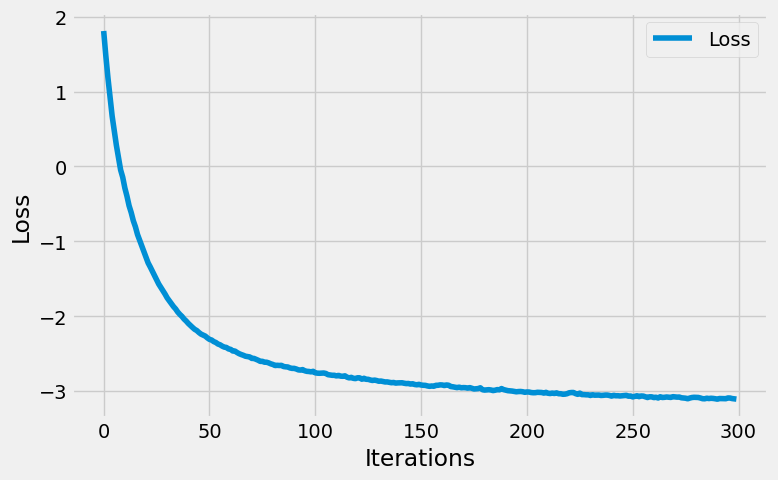

In [6]:
model_2D = Autoencoder()

optimizer = optim.Adam(model_2D.parameters(), lr=1e-3, weight_decay=1e-5)
epochs = 300
outputs = []
losses = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_2D.to(device)
loss_vs_epoch = []


for epoch in range(epochs):
    total_loss = 0
    for batch, label in loader_KDAE_train_data:
        features = batch.to(device)
        
        reconstructed = model_2D(features)
        latent = model_2D.shrinking(features)
        loss = loss_function(reconstructed, features,latent)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    loss_vs_epoch.append(total_loss)
    outputs.append((epoch, features, reconstructed))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.6f}")

plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(loss_vs_epoch, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

Plot de score van het model om te onderscheiden tussen de gelabelde en ongelabelde data

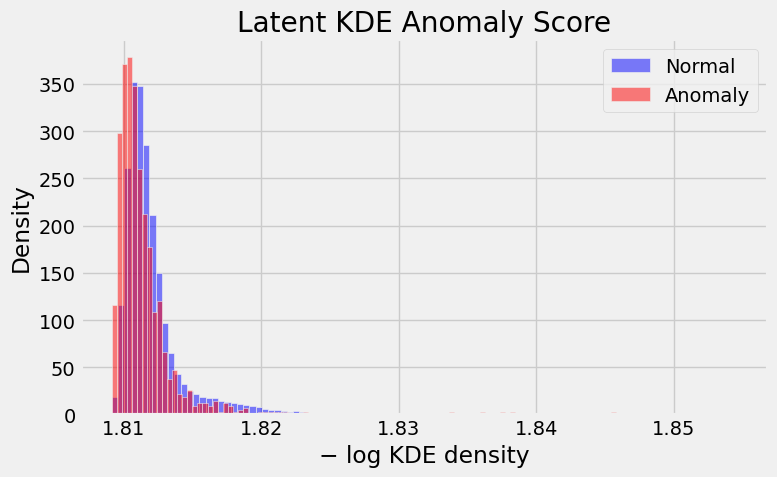

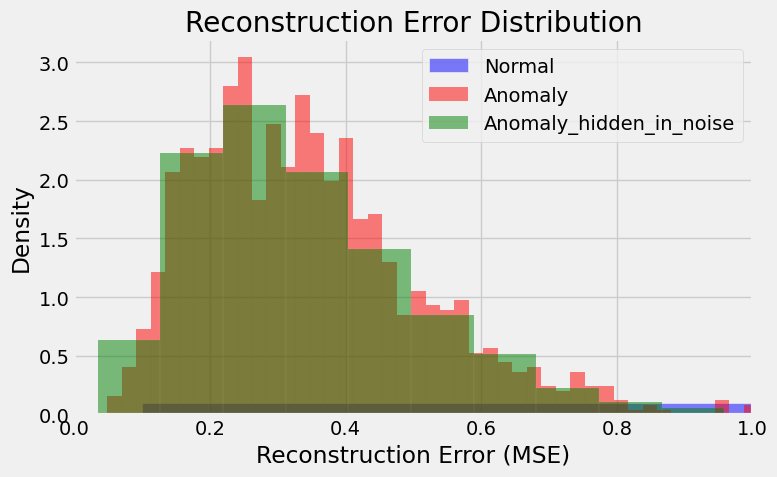

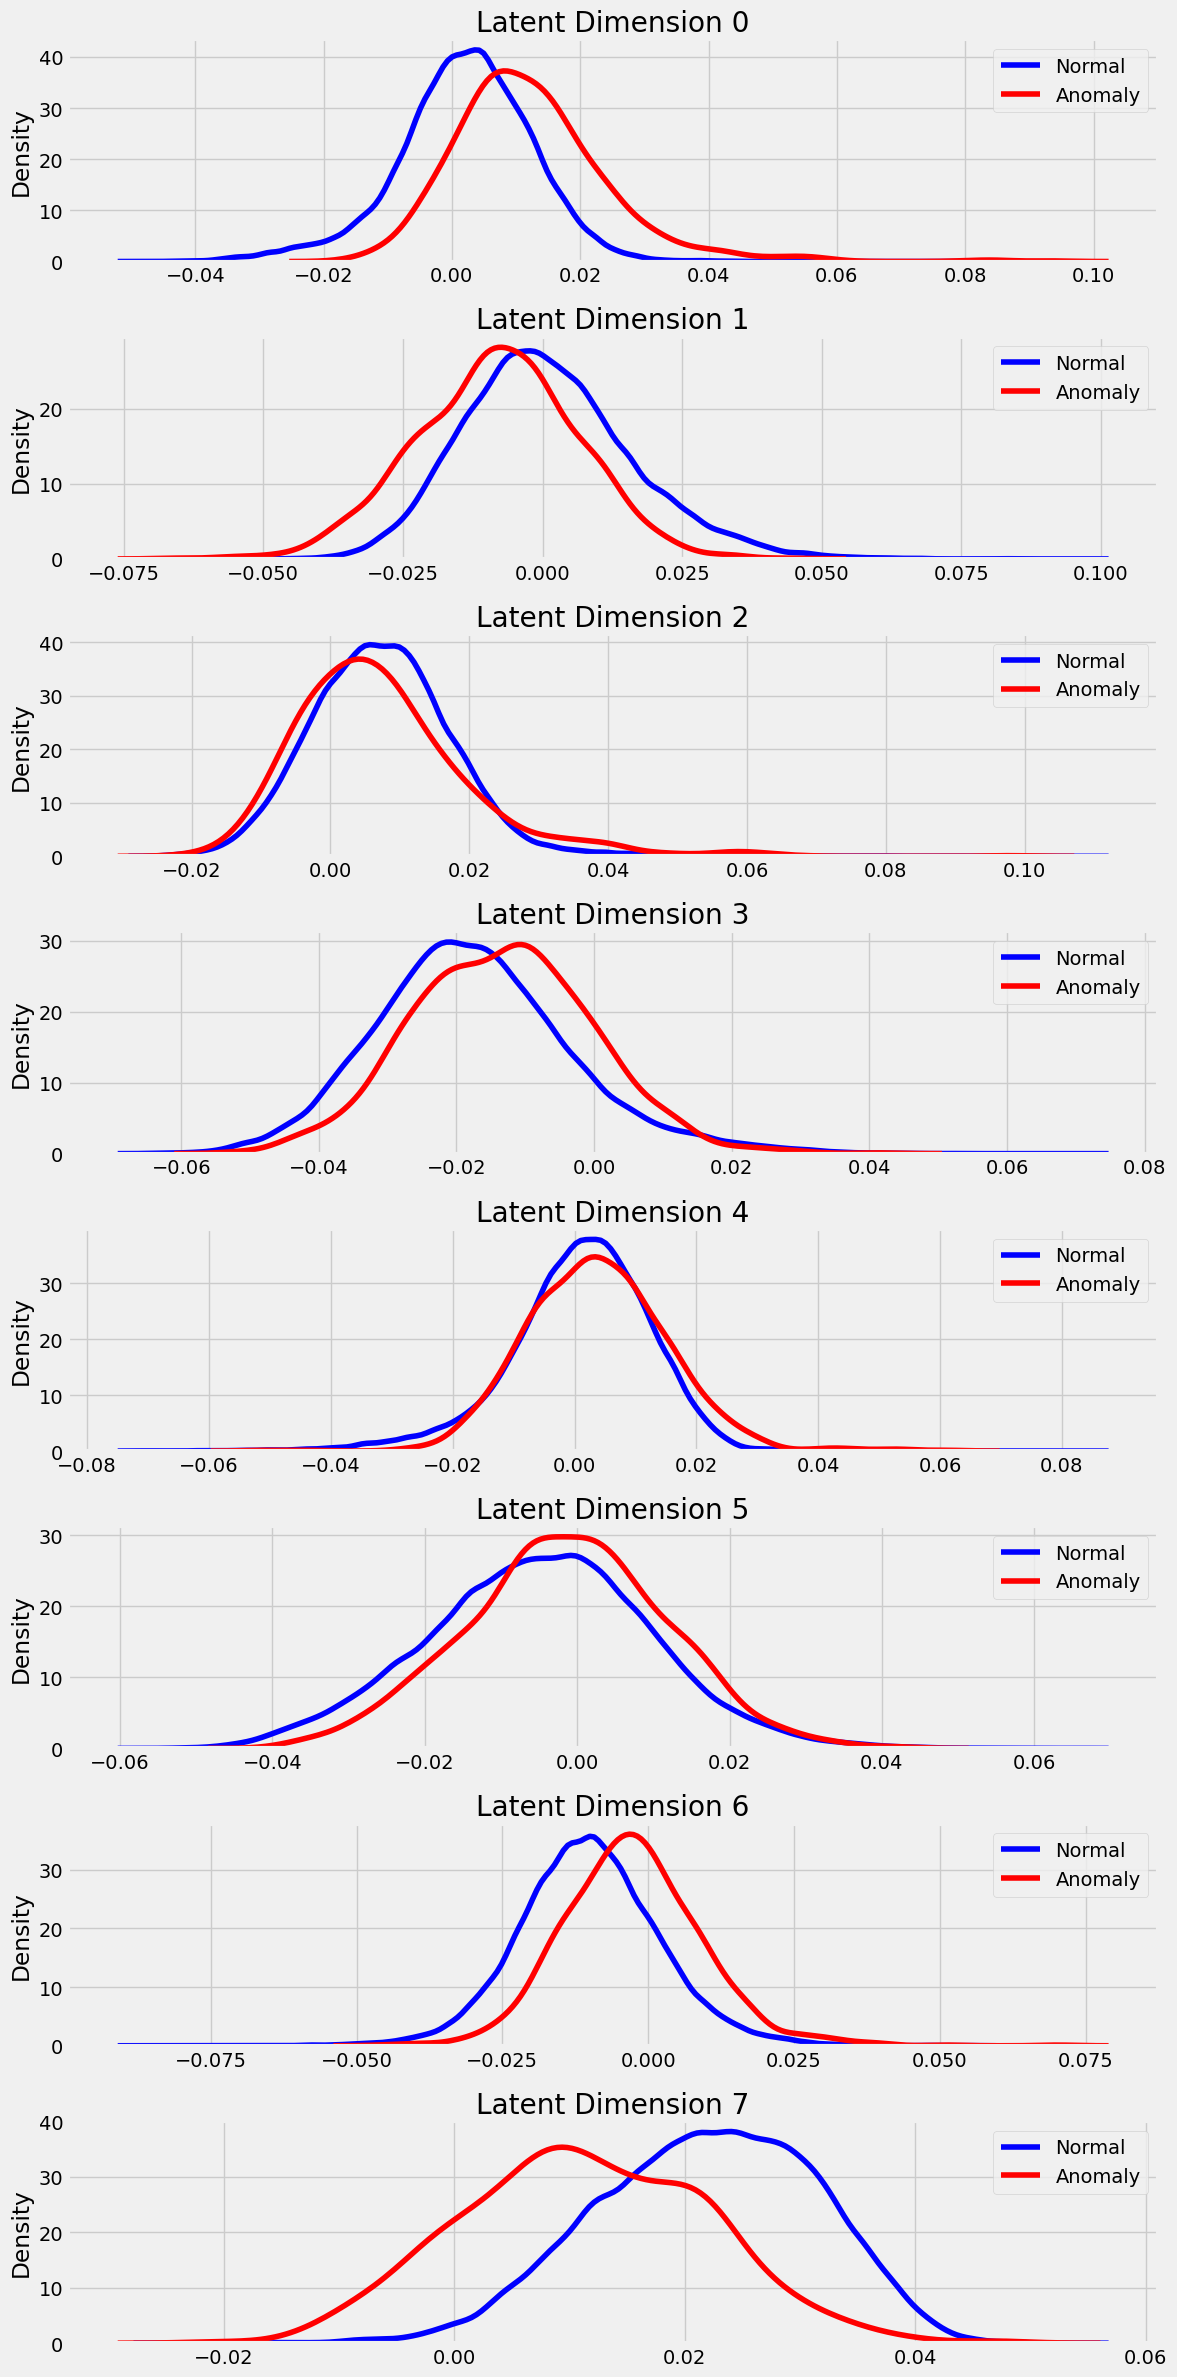

In [10]:
import torch
import numpy as np
from sklearn.neighbors import KernelDensity
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns


def collect_latent_and_error(model, dataloader, device):
    model.eval()

    latents = []
    recon_errors = []
    labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device).float()

            z = model.shrinking(x)
            recon = model(x)

            recon_error = torch.mean((x - recon) ** 2, dim=1)

            latents.append(z.cpu().numpy())
            recon_errors.append(recon_error.cpu().numpy())
            labels.append(y.cpu().numpy())

    return (
        np.vstack(latents),
        np.concatenate(recon_errors),
        np.concatenate(labels),
    )

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model_2D
model.to(device)

# Collect TRAIN (normal) data
latent_train, recon_train, y_train = collect_latent_and_error(
    model, loader_KDAE_train_data, device
)

# KDE fitted ONLY on (mostly) normal data
kde = KernelDensity(
    kernel="gaussian",
    bandwidth=0.5  # tune this!
).fit(latent_train)

latent_test, recon_test, y_test = collect_latent_and_error(
    model, loader_mixed_data, device
)

# KDE log-likelihood
log_density_test = kde.score_samples(latent_test)
log_density_train = kde.score_samples(latent_train)

# Anomaly scores
# (higher = more anomalous)
anomaly_score_kde = -log_density_test
anomaly_score_recon = -log_density_train


plt.figure(figsize=(8, 5))
sns.histplot(
    anomaly_score_kde[y_test == 0],
    bins=100,
    stat="density",
    label="Normal",
    color="blue",
    alpha=0.5,
)
sns.histplot(
    anomaly_score_kde[y_test == 1],
    bins=100,
    stat="density",
    label="Anomaly",
    color="red",
    alpha=0.5,
)

plt.xlabel("− log KDE density")
plt.title("Latent KDE Anomaly Score")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(
    recon_test[y_test == 0],
    bins=100,
    stat="density",
    label="Normal",
    color="blue",
    alpha=0.5,
)
sns.histplot(
    recon_test[y_test == 1],
    bins=100,
    stat="density",
    label="Anomaly",
    color="red",
    alpha=0.5,
)
sns.histplot(
    recon_train[y_train == 1],
    bins=100,
    stat="density",
    label="Anomaly_hidden_in_noise",
    color="green",
    alpha=0.5,
)
plt.xlabel("Reconstruction Error (MSE)")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.xlim(0,1)
plt.tight_layout()
plt.show()

latent_dim = latent_test.shape[1]
fig, axes = plt.subplots(latent_dim, 1, figsize=(12, 3 * latent_dim))

for i in range(latent_dim):
    sns.kdeplot(
        latent_test[y_test == 0, i],
        label="Normal",
        color="blue",
        ax=axes[i],
    )
    sns.kdeplot(
        latent_test[y_test == 1, i],
        label="Anomaly",
        color="red",
        ax=axes[i],
    )
    axes[i].set_title(f"Latent Dimension {i}")
    axes[i].legend()

plt.tight_layout()
plt.show()



Optimized threshold (Youden index): -1.810683681987185
Optimized threshold (max F1): -1.810683681987185
              precision    recall  f1-score   support

         0.0       0.99      0.76      0.86    100000
         1.0       0.02      0.47      0.04      1155

    accuracy                           0.75    101155
   macro avg       0.51      0.61      0.45    101155
weighted avg       0.98      0.75      0.85    101155

Confusion matrix:
 [[75744 24256]
 [  611   544]]
1155 true outlier amount


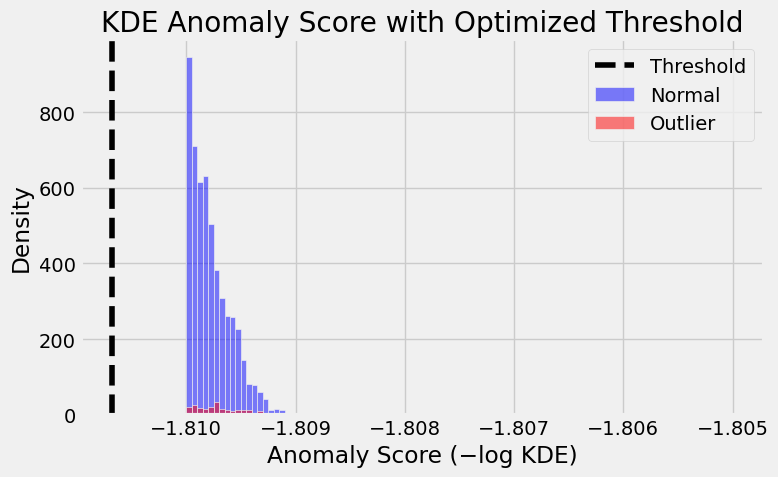

In [11]:
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score

fpr, tpr, thresholds = roc_curve(y_test, log_density_test)
youden_index = tpr - fpr
best_threshold = thresholds[np.argmax(youden_index)]
print("Optimized threshold (Youden index):", best_threshold)

precision, recall, pr_thresholds = precision_recall_curve(y_test, log_density_test)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold_f1 = pr_thresholds[np.argmax(f1_scores)]
print("Optimized threshold (max F1):", best_threshold)

pred_labels = (log_density_test > best_threshold).astype(int)
signal_mask = log_density_test > best_threshold



# Optional: check performance
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, pred_labels))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_labels))
print(len(log_density_test[y_test==1]),"true outlier amount")
plt.figure(figsize=(8,5))
sns.histplot(log_density_test[y_test==0], color='blue', label='Normal', binrange=(-1.810,-1.805),bins=100, alpha=0.5)
sns.histplot(log_density_test[y_test==1], color='red', label='Outlier', binrange=(-1.810,-1.805),bins=100, alpha=0.5)
plt.axvline(best_threshold, color='black', linestyle='--', label='Threshold')
plt.xlabel("Anomaly Score (−log KDE)")
plt.ylabel("Density")
plt.title("KDE Anomaly Score with Optimized Threshold")
plt.legend()
plt.tight_layout()
plt.show()



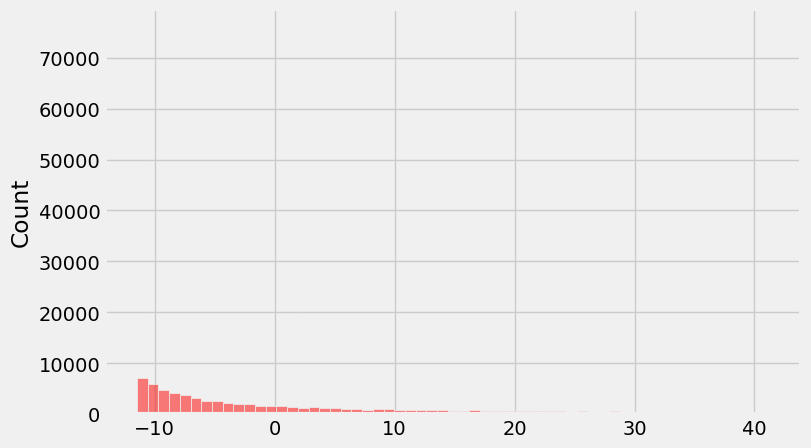

In [ ]:
# We have now classified the signal from the background (not necessarily very well). Give the signal we found in the background noise a label D+ = True
# Use ROC to find best threshold (Youden's J statistic)
latent_noise, recon_noise, y_noise = collect_latent_and_error(
    model, loader_noise_data, device
)
signal_mask = (kde.score_samples(latent_noise) > best_threshold).astype(int)
noise_mask =[not c for c in signal_mask]
X_Dplus_candidates = unlabeled_data_tensor_normalised[signal_mask]
X_Dplus_noise = unlabeled_data_tensor_normalised[noise_mask]
plt.figure(figsize=(8,5))
sns.histplot(X_Dplus_candidates[:,0], color='blue', label='Normal', alpha=0.5)
sns.histplot(X_Dplus_noise[:,0], color='red', label='Outlier', alpha=0.5)
plt.show()

In [ ]:
# from sklearn.neighbors import KernelDensity

# model = model_2D
# model.eval()
# with torch.no_grad():
#     latent_labeled = model.shrinking(labeled_tensor.to(device).float()).cpu().numpy()
#     latent_unlabeled = model.shrinking(unlabeled_tensor.to(device).float()).cpu().numpy()

# kde = KernelDensity(kernel='gaussian').fit(latent_labeled)


# # plt.figure()
# # plt.plot(kde.score_samples(x_plot))
# # plt.show()
# def anomaly_score(model, x, kde, device='cpu'):
#     model.eval()
#     x = x.to(device).float()
#     with torch.no_grad():
#         latent = model.shrinking(x).cpu().numpy()
#         recon = model(x)
#         recon_error = torch.mean((x - recon)**2, dim=1).cpu().numpy()
#         latent_density = kde.score_samples(latent)  # log-likelihood
#     # High error + low density → anomaly
#     return recon_error, latent_density

# def latent_values(model,x):
#     x = x.to(device).float()
#     with torch.no_grad():
#         return model.shrinking(x).cpu().numpy()

# # normal_data: Tensor, outlier_data: Tensor
# scores_normal, latent_score = anomaly_score(model, unlabeled_tensor, kde)
# scores_outlier, latent_score_outlier = anomaly_score(model, labeled_tensor, kde)
# print(np.shape(latent_score))
# plt.figure(figsize=(8, 5))
# print(latent_score)
# sns.histplot(latent_score, label='Normal', color='blue',alpha=0.5,stat='proportion',bins=100,kde=True,fill=True)
# sns.histplot(latent_score_outlier, label='Outlier', color='red',alpha=0.5,stat='proportion',bins=100,kde=True,fill=True)
#                         # log-scale on x-axis
# plt.xlabel("Anomaly Score (log scale)")
# plt.ylabel("Density")
# plt.title("Normal vs Outlier Score Distributions")
# plt.legend()

# plt.tight_layout()
# plt.show()

# # Column names
# columns = ['latent1','latent2','latent3','latent4']

# # Plot histograms for each feature
# fig, axes = plt.subplots(4,1, figsize=(12, 10))
# axes = axes.flatten()
# latent_test = latent_values(model, unlabeled_tensor)
# latent_train = latent_values(model,labeled_tensor)

# for i in [0,1,2,3]:
#     sns.kdeplot(latent_test[:, i], color='blue', alpha=0.5, label='Train', ax=axes[i])
#     sns.kdeplot(latent_train[:, i], color='red', alpha=0.5, label='Test', ax=axes[i])
#     axes[i].set_title(columns[i])
#     axes[i].legend()

# plt.tight_layout()
# plt.show()

# from sklearn.metrics import mean_squared_error

# model.eval()
# x = labeled_tensor.to(device).float()
# with torch.no_grad():
#     latent = model.shrinking(x).cpu().numpy()
#     recon = model(x)
#     recon_error_train = torch.mean((x - recon)**2, dim=1).cpu().numpy()
#     print(recon_error_train,"recon_Error_train")
# # High error + low density → anomaly


# print("mean squared error: ",np.average(recon_error_train))

# model.eval()
# x = unlabeled_tensor.to(device).float()
# with torch.no_grad():
#     latent = model.shrinking(x).cpu().numpy()
#     recon = model(x)
#     recon_error = torch.mean((x - recon)**2, dim=1).cpu().numpy()
# # High error + low density → anomaly

# # plt.hist(recon_error_train,density=True,bins=100,label='train',range=[0,.2])
# plt.hist(recon_error_train,density=True,bins=100,label='train',range=[0,.5])
# plt.hist(recon_error,density=True,bins=100,label='test',range=[0,.5])
# plt.legend()
# plt.plot()
# print("mean squared error: ",np.average(recon_error))

In [ ]:

# x = labeled_tensor.to(device).float()
# with torch.no_grad():
#     y = model_2D.forward(x)

# x_test = unlabeled_tensor.to(device).float()
# with torch.no_grad():
#     y_test = model_2D.forward(x_test)


# # Column names
# columns = branches

# # Plot histograms for each feature
# fig, axes = plt.subplots(4,4, figsize=(40, 40))
# axes = axes.flatten()

# for i, col in enumerate(columns):
#     sns.histplot(x_test[:,i], bins=50, color='blue', alpha=0.5, label='test_input', ax=axes[i],kde=True,stat='proportion')
#     sns.histplot(y_test[:,i], bins=50, color='red', alpha=0.5, label='test_output', ax=axes[i],kde=True,stat='proportion')
#     sns.histplot(x[:,i], bins=50, color='black', alpha=0.5, label='train_input', ax=axes[i],kde=True,stat='proportion')
#     sns.histplot(y[:,i], bins=50, color='green', alpha=0.5, label='train_output', ax=axes[i],kde=True,stat='proportion')
#     axes[i].set_title(col)
#     axes[i].legend()

# plt.tight_layout()
# plt.show()

In [ ]:
# import seaborn as sns
# def loader_to_tensor(loader):
#     all_data = []
#     for batch in loader:
#         # batch is a tuple (features,) because no labels
#         all_data.append(batch[0])
#     return torch.cat(all_data, dim=0)
# # Convert train and test loaders
# train_tensor = loader_to_tensor(loader)
# test_tensor = loader_to_tensor(loader_test)

# # Convert to numpy for plotting
# train_np = train_tensor.numpy()
# test_np = test_tensor.numpy()

# # Column names
# columns = ['inv_mass','d_len','pt_cand','d_len_xy']

# # Plot histograms for each feature
# fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# axes = axes.flatten()

# for i, col in enumerate(columns):
#     sns.histplot(train_np[:, i], bins=50, color='blue', alpha=0.5, label='Train', ax=axes[i],kde=True,stat='proportion')
#     sns.histplot(test_np[:, i], bins=50, color='red', alpha=0.5, label='Test', ax=axes[i],kde=True,stat='proportion')
#     axes[i].set_title(col)
#     axes[i].legend()

# plt.tight_layout()
# plt.show()